# 00 — Getting Started

zbi es un pipeline de SBI (Simulation-Based Inference) que entrena MAFs (Masked Autoregressive Flows) con truncamiento secuencial del prior (tSNPE). Está construido sobre PyTorch y nflows.

En este tutorial:
1. Definir un simulador y una red de embedding
2. Inicializar un experimento y simular 10000 datos
3. Entrenar 3 modelos por separado y compararlos
4. Entrenar un ensamble de 3 modelos y compararlos

In [1]:
import os
import shutil
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
import zbi

%matplotlib inline

## 1. Simulador gaussiano

Detector que mide una señal en 100 puntos. La señal es una recta con pendiente $a$ e intercepto $b$, más ruido Gaussiano:

$$x_i = a \cdot g_i + b + \epsilon_i, \quad \epsilon_i \sim \mathcal{N}(0, 0.1)$$

In [2]:
class SimuladorLineal(zbi.Simulator):
    def __init__(self):
        super().__init__()
        self.x_grid = torch.linspace(-5, 5, 100)

    def simulate(self, theta: torch.Tensor, seed: int | None = None) -> torch.Tensor:
        if seed is not None:
            torch.manual_seed(seed)
        a, b = theta[0].item(), theta[1].item()
        return a * self.x_grid + b + 0.5 * torch.randn(100)

## 2. Red de embedding

Proyecta el dato de 100 dimensiones a 5 con una capa lineal.

In [3]:
class EmbeddingNet(nn.Module):
    def __init__(self, dim_in: int = 100, dim_out: int = 5):
        super().__init__()
        self.net = nn.Linear(dim_in, dim_out)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

## 3. Observación y experimento

Prior Uniforme en $[0.8, 0.2]$ y $[1.2, 0.8]$. Valor verdadero: $\theta_{\text{true}} = (1.0, 0.5)$.

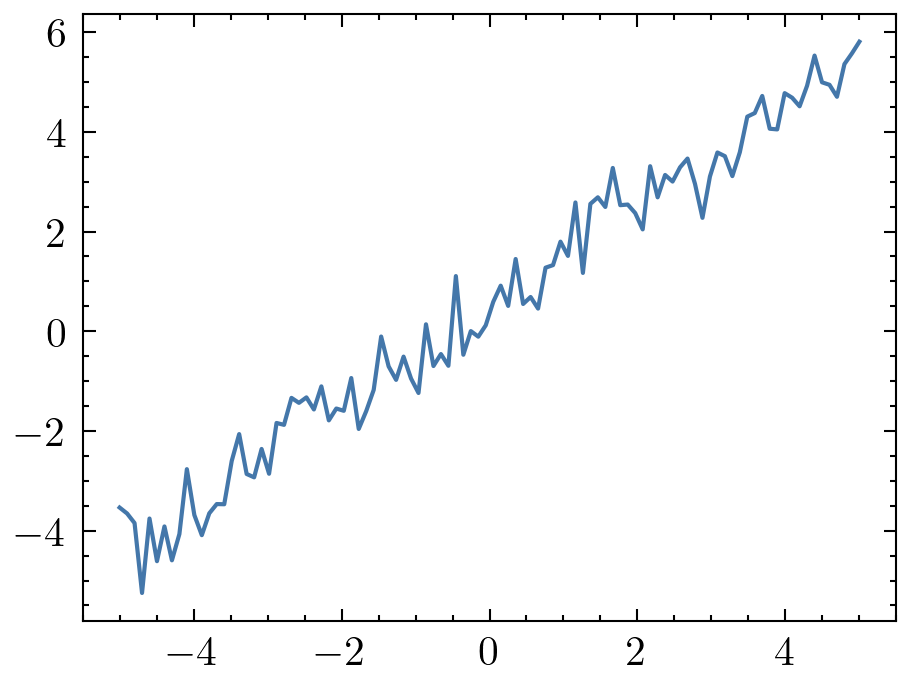

In [4]:
x_grid = torch.linspace(-5, 5, 100)
x_o = zbi.simulate_obs(SimuladorLineal(), theta_true=(1.0, 0.5), seed=42)
plt.plot(x_grid, x_o[0])

In [ ]:
run_dir = "runs/tutorial_00"
if os.path.exists(run_dir):
    shutil.rmtree(run_dir)

zbi.init(
    run_dir=run_dir, x_o=x_o,
    simulator_class=SimuladorLineal,
    embedding_class=EmbeddingNet,
    embedding_kwargs=dict(dim_in=100, dim_out=5),
    prior_low=(0.8, 0.2), prior_high=(1.2, 0.8),
    dim_theta=2, dim_x=100,
    zarr_N=50000, zarr_chunk_size=128
    maf_kwargs=dict(
        hidden_features=32, num_transforms=5,
        num_blocks=2, dropout_probability=0.0,
        use_batch_norm=False
    )
)
print("Experimento inicializado")

Experimento inicializado


In [ ]:
zbi.simulate(run_dir=run_dir, round=0, n_sims=10000, seed=1)
print("10000 simulaciones listas")

Simulating: 100%|██████████| 10000/10000 [00:03<00:00, 2838.95it/s]


Round 0: 10000 new sims, 10000 accumulated (offset=0)
10000 simulaciones listas


## 4. Tres modelos entrenados por separado

Entrenamos 3 modelos independientes con `zbi.train`, cada uno con un `tag` distinto para que no se sobreescriban.

In [ ]:
zbi.train(
    run_dir=run_dir, 
    round=0, 
    n_sims=10000, 
    max_epochs=200, 
    stop_after_epochs=20, 
    tag="a", 
    load_to_ram=True
)

Using simulations: offset=0, n_sims=10000
Epoch   0  train_loss=-1.8481  val_loss=-3.7872
Epoch   1  train_loss=-4.0199  val_loss=-4.1335
Epoch   2  train_loss=-4.1793  val_loss=-4.2125
Epoch   3  train_loss=-4.2154  val_loss=-4.2403
Epoch   4  train_loss=-4.2326  val_loss=-4.2243
Epoch   5  train_loss=-4.2471  val_loss=-4.2514
Epoch   6  train_loss=-4.2560  val_loss=-4.2638
Epoch   7  train_loss=-4.2618  val_loss=-4.2552
Epoch   8  train_loss=-4.2654  val_loss=-4.2470
Epoch   9  train_loss=-4.2797  val_loss=-4.2721
Epoch  10  train_loss=-4.2837  val_loss=-4.2625
Epoch  11  train_loss=-4.2909  val_loss=-4.2840
Epoch  12  train_loss=-4.2889  val_loss=-4.2825
Epoch  13  train_loss=-4.2959  val_loss=-4.3024
Epoch  14  train_loss=-4.2990  val_loss=-4.3106
Epoch  15  train_loss=-4.3046  val_loss=-4.2943
Epoch  16  train_loss=-4.3019  val_loss=-4.2956
Epoch  17  train_loss=-4.3037  val_loss=-4.2915
Epoch  18  train_loss=-4.3072  val_loss=-4.2791
Epoch  19  train_loss=-4.3171  val_loss=-4.310

In [ ]:
zbi.train(
    run_dir=run_dir, 
    round=0, 
    n_sims=10000, 
    max_epochs=200, 
    stop_after_epochs=20, 
    tag="b", 
    load_to_ram=True
)

Using simulations: offset=0, n_sims=10000
Epoch   0  train_loss=-1.8517  val_loss=-3.7759
Epoch   1  train_loss=-4.0530  val_loss=-4.0725
Epoch   2  train_loss=-4.2010  val_loss=-4.1715
Epoch   3  train_loss=-4.2352  val_loss=-4.1672
Epoch   4  train_loss=-4.2546  val_loss=-4.1967
Epoch   5  train_loss=-4.2699  val_loss=-4.2029
Epoch   6  train_loss=-4.2700  val_loss=-4.1693
Epoch   7  train_loss=-4.2798  val_loss=-4.1721
Epoch   8  train_loss=-4.2807  val_loss=-4.1895
Epoch   9  train_loss=-4.2906  val_loss=-4.1930
Epoch  10  train_loss=-4.2920  val_loss=-4.2269
Epoch  11  train_loss=-4.3010  val_loss=-4.2087
Epoch  12  train_loss=-4.3126  val_loss=-4.2278
Epoch  13  train_loss=-4.3065  val_loss=-4.1844
Epoch  14  train_loss=-4.3142  val_loss=-4.2104
Epoch  15  train_loss=-4.3146  val_loss=-4.2126
Epoch  16  train_loss=-4.3228  val_loss=-4.2082
Epoch  17  train_loss=-4.3209  val_loss=-4.2060
Epoch  18  train_loss=-4.3270  val_loss=-4.2345
Epoch  19  train_loss=-4.3259  val_loss=-4.255

In [ ]:
zbi.train(
    run_dir=run_dir, 
    round=0, 
    n_sims=10000, 
    max_epochs=200, 
    stop_after_epochs=20, 
    tag="c", 
    load_to_ram=True
)

Using simulations: offset=0, n_sims=10000
Epoch   0  train_loss=-1.6910  val_loss=-3.3963
Epoch   1  train_loss=-3.9381  val_loss=-4.1110
Epoch   2  train_loss=-4.1582  val_loss=-4.1758
Epoch   3  train_loss=-4.2099  val_loss=-4.2578
Epoch   4  train_loss=-4.2339  val_loss=-4.2617
Epoch   5  train_loss=-4.2494  val_loss=-4.2578
Epoch   6  train_loss=-4.2563  val_loss=-4.2782
Epoch   7  train_loss=-4.2642  val_loss=-4.2287
Epoch   8  train_loss=-4.2719  val_loss=-4.2935
Epoch   9  train_loss=-4.2765  val_loss=-4.2840
Epoch  10  train_loss=-4.2799  val_loss=-4.2588
Epoch  11  train_loss=-4.2821  val_loss=-4.3231
Epoch  12  train_loss=-4.2923  val_loss=-4.2957
Epoch  13  train_loss=-4.2926  val_loss=-4.3159
Epoch  14  train_loss=-4.3024  val_loss=-4.3135
Epoch  15  train_loss=-4.3068  val_loss=-4.2848
Epoch  16  train_loss=-4.3062  val_loss=-4.3081
Epoch  17  train_loss=-4.3029  val_loss=-4.2872
Epoch  18  train_loss=-4.3079  val_loss=-4.3267
Epoch  19  train_loss=-4.3162  val_loss=-4.322

### Comparar los 3 modelos

Removed no burn in
Removed no burn in
Removed no burn in


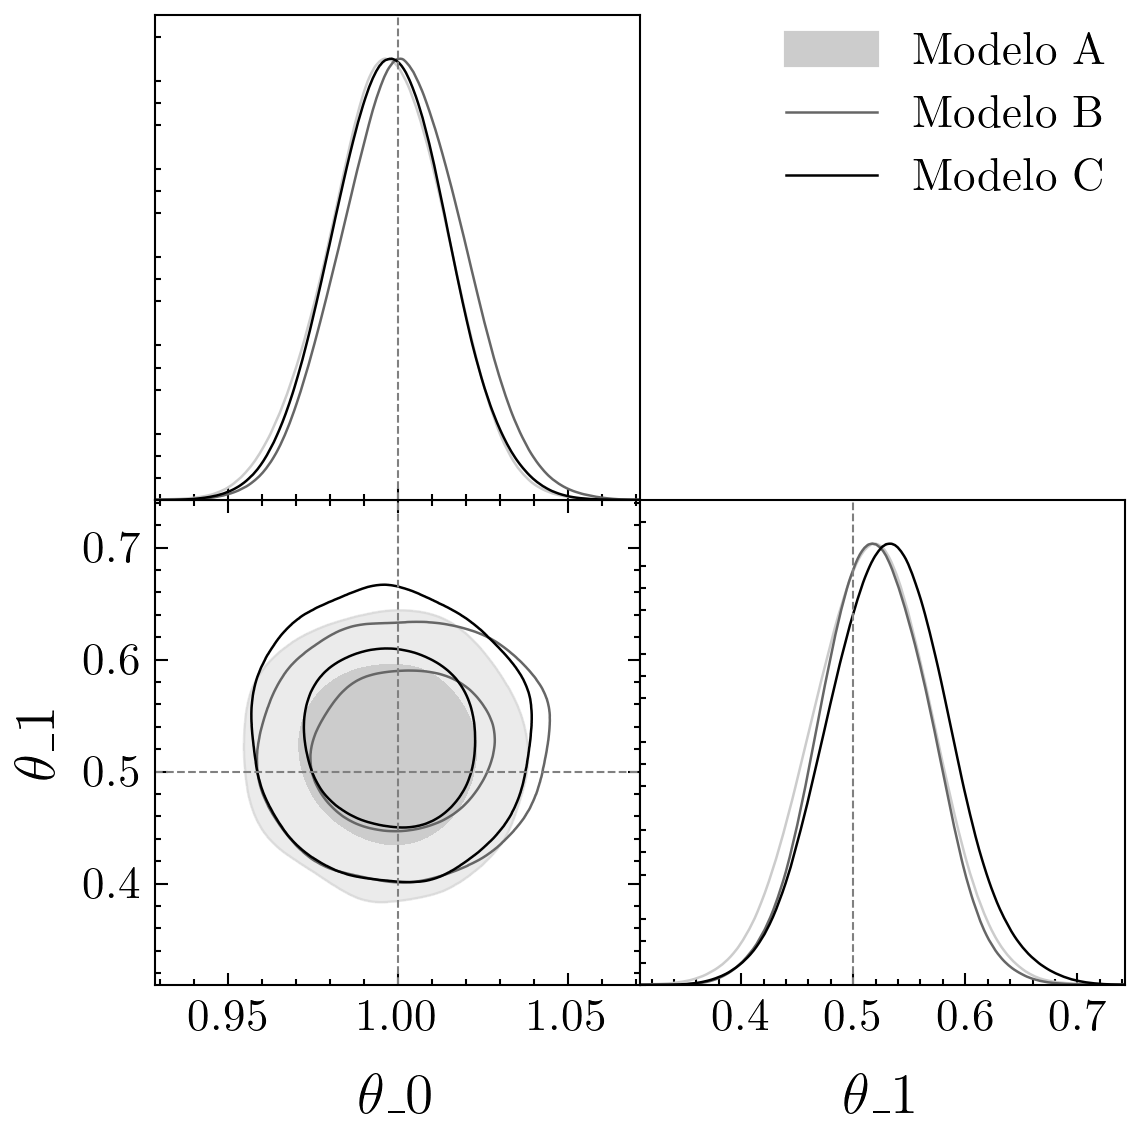

In [10]:
samples_a = zbi.sample_model(run_dir, "round_00000_10000_a.pt", n_samples=10_000)
samples_b = zbi.sample_model(run_dir, "round_00000_10000_b.pt", n_samples=10_000)
samples_c = zbi.sample_model(run_dir, "round_00000_10000_c.pt", n_samples=10_000)

zbi.plot_ppc(
    all_samples=[samples_a, samples_b, samples_c],
    param_names=[r'\theta_0', r'\theta_1'],
    true_parameter=[1.0, 0.5],
    sample_labels=["Modelo A", "Modelo B", "Modelo C"],
    legend_fontsize=11,
    # limits=[(0.8, 1.2), (0.2, 0.8)],
    filled=[True, False, False],
    sample_colors=["#cccccc", "#666666", "#000000"],
    gdist_fine_bins=2000,
    gdist_scaling_factor=0.1
)

## Resumen

| Función | Descripción |
|---------|-------------|
| `zbi.init()` | Inicializa experimento |
| `zbi.simulate()` | Samplea del prior y guarda en ZarrStore |
| `zbi.train()` | Entrena un MAF individual |
| `zbi.sample_model()` | Genera muestras de la posterior |
| `zbi.plot_ppc()` | Corner plot con getdist |